In [1]:
import hist
from coffea.util import load, save
import mplhep as hep
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
from tabulate import tabulate
import uncertainties as unc  
import uncertainties.unumpy as unumpy 
plt.style.use(hep.style.CMS)


In [24]:
hists = load('./hadmonotopphotrieff3.scaled')
year = '2022'
lumi = {
    '2022': 7.98
}

In [25]:
from scipy.special import betaincinv # type: ignore

def ClopperPearson(total, passed, level=0.68):
    """
    Clopper-Pearson method for calculating confidence intervals.
    :param total: Array of total events
    :param passed: Array of events that passed the selection
    :param level: Confidence level (0.68 for 1 sigma, 0.95 for 2 sigma, etc.)
    :return: Lower and upper bounds of the confidence interval
    """
    alpha = 1 - level
    lower_bound = betaincinv(passed, total - passed + 1, alpha / 2)
    upper_bound = betaincinv(passed + 1, total - passed, 1 - alpha / 2)
    # nan to 0 for lower bound and 1 for upper bound
    lower_bound = np.where(np.isnan(lower_bound), 0, lower_bound)
    upper_bound = np.where(np.isnan(upper_bound), 1, upper_bound)
    return lower_bound, upper_bound

In [62]:
hists

{'bkg': {'sumw': {'G + Jets': 302691900000.0},
  'template': {'G + Jets': Hist(
     StrCategory(['basic', 'oneA', 'eff'], growth=True, name='region'),
     Regular(60, 0, 1200, name='phopt', label='Photon Pt'),
     Variable([-0.5, 0.5, 1.5], name='PFHT1050', label='Reference trigger'),
     Variable([-0.5, 0.5, 1.5], name='Photon200', label='Photon trigger'),
     storage=Weight()) # Sum: WeightedSum(value=3.83719e+07, variance=3.83719e+07) (WeightedSum(value=1.08026e+08, variance=1.08026e+08) with flow)},
  'phopt': {'G + Jets': Hist(
     StrCategory(['basic', 'oneA', 'eff'], growth=True, name='region'),
     Regular(24, 0, 1200, name='phopt', label='Leading Photon Pt'),
     Integer(0, 2, name='PFHT1050', label='Reference trigger'),
     Integer(0, 2, name='Photon200', label='Photon trigger'),
     storage=Weight()) # Sum: WeightedSum(value=3.83719e+07, variance=3.83719e+07) (WeightedSum(value=1.08026e+08, variance=1.08026e+08) with flow)},
  'phoeta': {'G + Jets': Hist(
     StrC

In [64]:
num_data = hists['data']['phopt']['MET'][{'region':'eff','PFHT1050':1, 'Photon200':1}].project('phopt')#.values()
den_data = hists['data']['phopt']['MET'][{'region':'eff','PFHT1050':1}].project('phopt')#.values()

In [65]:
err_low, err_up = ClopperPearson(den_data.values(), num_data.values(), level=0.68)
print(err_low)
print(err_up)

[0.         0.         0.         0.         0.97150683 0.9836258
 0.97553951 0.97553951 0.96175927 0.9552191  0.93194274 0.94259786
 0.93437877 0.89177953 0.91643349 0.83255321 0.83255321 0.83255321
 0.84653959 0.69314484 0.63245553 0.54288352 0.4        0.69314484]
[1.         1.         1.         1.         0.99557343 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.        ]


[  0.   0.   0.   0. 161. 111.  74.  74.  47.  40.  26.  31.  27.  16.
  21.  10.  10.  10.  11.   5.   4.   3.   2.   5.]
[  0.   0.   0.   0. 159. 111.  74.  74.  47.  40.  26.  31.  27.  16.
  21.  10.  10.  10.  11.   5.   4.   3.   2.   5.]
[0.98757764 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]
[array([0.        , 0.        , 0.        , 0.        , 0.01607081,
       0.0163742 , 0.02446049, 0.02446049, 0.03824073, 0.0447809 ,
       0.06805726, 0.05740214, 0.06562123, 0.10822047, 0.08356651,
       0.16744679, 0.16744679, 0.16744679, 0.15346041, 0.30685516,
       0.36754447, 0.45711648, 0.6       , 0.30685516]), array([1.        , 1.        , 1.        , 1.        , 0.00799579,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.     

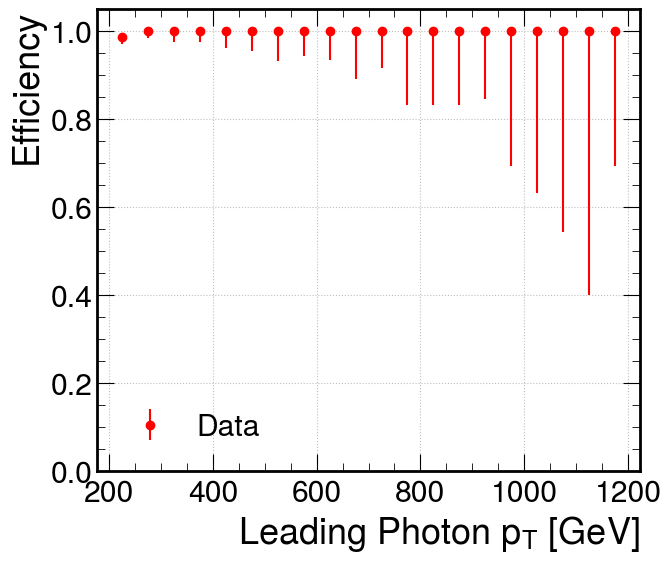

In [67]:
print(den_data.values())
print(num_data.values())
#eff_data = num_data.values()/den_data.values()
x = num_data.axes["phopt"].centers

num_data_val = num_data.values()
den_data_val = den_data.values()
eff = np.divide(
    num_data_val,
    den_data_val,
    out=np.zeros_like(num_data_val),
    where=den_data_val > 0
)
mask = (den_data_val > 0)# & (num_data_val > 0)

eff_err = np.zeros_like(eff)

eff_err[mask] = np.sqrt(
    eff[mask] * (1 - eff[mask]) / den_data_val[mask]
)
mask = den_data_val > 0
plt.figure(figsize=(7,6))
print(eff[mask])
print([np.abs(eff - err_low), np.abs(eff - err_up)])
plt.errorbar(
    x[mask],
    eff[mask],
    yerr=[np.abs(eff[mask] - err_low[mask]), np.abs(eff[mask] - err_up[mask])],#eff_err[mask],
    fmt='o',
    color='red',
    label='Data'
)
plt.xlabel("Leading Photon $p_T$ [GeV]")
plt.ylabel("Efficiency")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

In [68]:
#den = hists['bkg']['phopt']['G + Jets'][{'region':'eff','PFHT1050':1, 'Photon200':sum}]#.values()
num = hists['bkg']['phopt']['G + Jets'][{'region':'eff','PFHT1050':1, 'Photon200':1}].project('phopt')#.values()
den = hists['bkg']['phopt']['G + Jets'][{'region':'eff','PFHT1050':1, 'Photon200':sum}].project('phopt')#.values()

In [70]:
err_low, err_up = ClopperPearson(den.values(), num.values(), level=0.68)
print(err_low)
print(err_up)
den.variances()

[0.         0.         0.         0.         0.95668118 0.99869187
 0.99873608 0.99927706 0.99977161 0.99946546 0.99965486 0.99964739
 0.99973348 0.99985353 0.99989283 0.99992647 0.99990499 0.99969756
 0.99962503 0.99955194 0.99962101 0.99975009 0.9997243  0.99943303]
[1.         1.         1.         1.         0.96664257 1.
 1.         1.         1.         0.99991769 0.9999817  0.99994571
 0.99992195 0.99997745 0.99999432 1.         1.         0.99995343
 0.99994226 0.99993101 0.9999799  1.         1.         0.99996993]


array([    0.,     0.,     0.,     0.,  1656.,  1400.,  1449.,  2534.,
        8023.,  8651.,  9527., 13115., 26814., 31575., 30685., 24921.,
       19287., 15291., 12333., 10321.,  8676.,  7332.,  6646.,  5799.])

In [25]:
num_val = num.values()
den_val = den.values()

eff = np.divide(
    num_val,
    den_val,
    out=np.zeros_like(num_val),
    where=den_val > 0
)

eff_err = np.sqrt(
    eff * (1 - eff) / den_val,
    where=den_val > 0
)


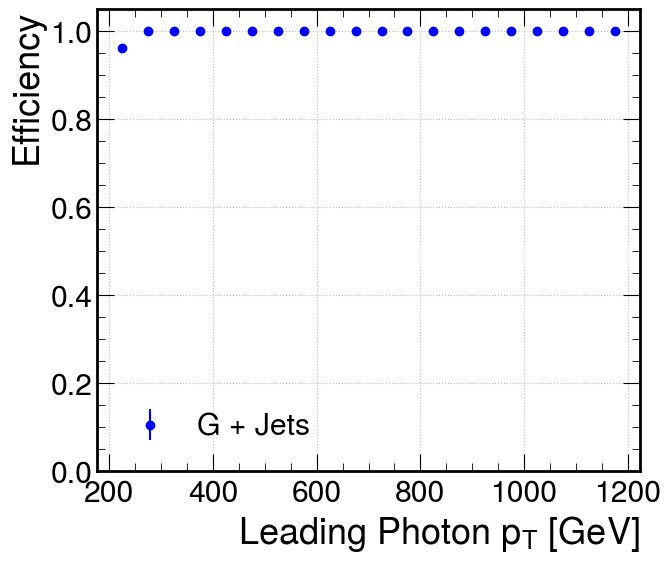

In [71]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num.axes["phopt"].centers
#hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')
plt.figure(figsize=(7,6))
plt.errorbar(
    x,
    eff,
    yerr=[np.abs(eff - err_low), np.abs(eff - err_up)],
    #yerr=eff_err,
    fmt='o',
    label='G + Jets',
    color='blue'
)

plt.xlabel("Leading Photon $p_T$ [GeV]")
plt.ylabel("Efficiency")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## SF

In [26]:
h_data = hists['data']['phopt']['MET']

num_data = h_data[
    {'region':'eff', 'PFHT1050':1, 'Photon200':1}
].project('phopt')

den_data = h_data[
    {'region':'eff', 'PFHT1050':1}
].project('phopt')

In [27]:
h_mc = hists['bkg']['phopt']['G + Jets']

num_mc = h_mc[
    {'region':'eff', 'PFHT1050':1, 'Photon200':1}
].project('phopt')

den_mc = h_mc[
    {'region':'eff', 'PFHT1050':1}
].project('phopt')

In [28]:
import numpy as np

def efficiency(num, den):
    num_v = num.values()
    den_v = den.values()



    eff = np.divide(
        num_v, den_v,
        out=np.zeros_like(num_v),
        where=den_v > 0
    )

    err = np.zeros_like(eff)
    mask = den_v > 0

    #err = [np.abs(eff[mask] - err_low[mask]), np.abs(eff[mask] - err_up[mask])],
    err[mask] = np.sqrt(
        eff[mask] * (1 - eff[mask]) / den_v[mask]
    )

    return eff, err

In [29]:
data_err_low, data_err_up = ClopperPearson(den_data.values(), num_data.values(), level=0.68)
#mc_err_low, mc_err_up = ClopperPearson(den_mc.values(), num_mc.values(), level=0.68)


In [30]:
eff_data, err_data = efficiency(num_data, den_data)
eff_mc,   err_mc   = efficiency(num_mc, den_mc)
sf = np.divide(
    eff_data, eff_mc,
    out=np.zeros_like(eff_data),
    where=eff_mc > 0
)

#mask = (den_data.values() > 0) & (den_mc.values() > 0)
#err_data = [np.abs(eff_data[mask] - data_err_low[mask]), np.abs(eff_data[mask] - data_err_up[mask])]
print(err_data)

[0.         0.         0.         0.         0.00872921 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]


In [31]:
sf_err = np.zeros_like(sf)

mask = (eff_mc > 0) & (eff_data > 0)
print(err_data)
print(eff_data)
sf_err = sf[mask] * np.sqrt(
    (err_data[mask] / eff_data[mask])**2 +
    (err_mc[mask]   / eff_mc[mask])**2
)

[0.         0.         0.         0.         0.00872921 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]
[0.         0.         0.         0.         0.98757764 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.        ]


[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.70097199e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.63455101e-04 1.04959328e-04 1.07823540e-04
 7.45823383e-05 4.47876096e-05 3.25886819e-05 0.00000000e+00
 0.00000000e+00 9.24806143e-05 1.14659766e-04 1.37009644e-04
 1.15253846e-04 0.00000000e+00 0.00000000e+00 1.72428656e-04]


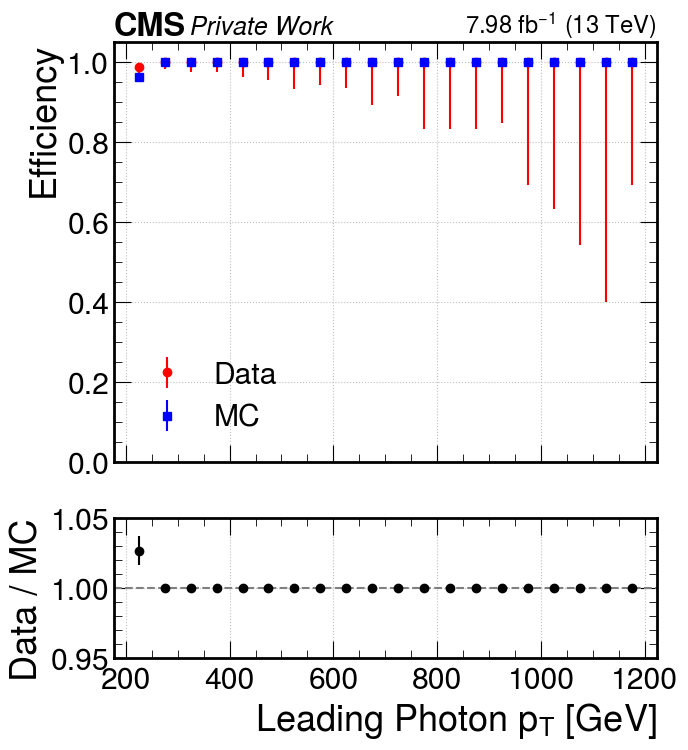

In [32]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num_data.axes["phopt"].centers
mask = (den_data.values() > 0) & (den_mc.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_data[mask], yerr=[np.abs(eff_data[mask] - data_err_low[mask]), np.abs(eff_data[mask] - data_err_up[mask])],
    fmt='o', label='Data', color='red',
)
ax1.errorbar(
    x[mask], eff_mc[mask], yerr=err_mc[mask],
    fmt='s', label='MC', color='blue',
)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
ax2.errorbar(
    x[mask], sf[mask], yerr=sf_err,#[mask],
    fmt='o', color='black'
)
print(err_mc)
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel("Leading Photon $p_T$ [GeV]")
ax2.set_ylim(0.95, 1.05)
ax2.grid(True)

plt.show()


# Back-up

G + Jets


NotImplementedError: Please project to 1D before calling plot

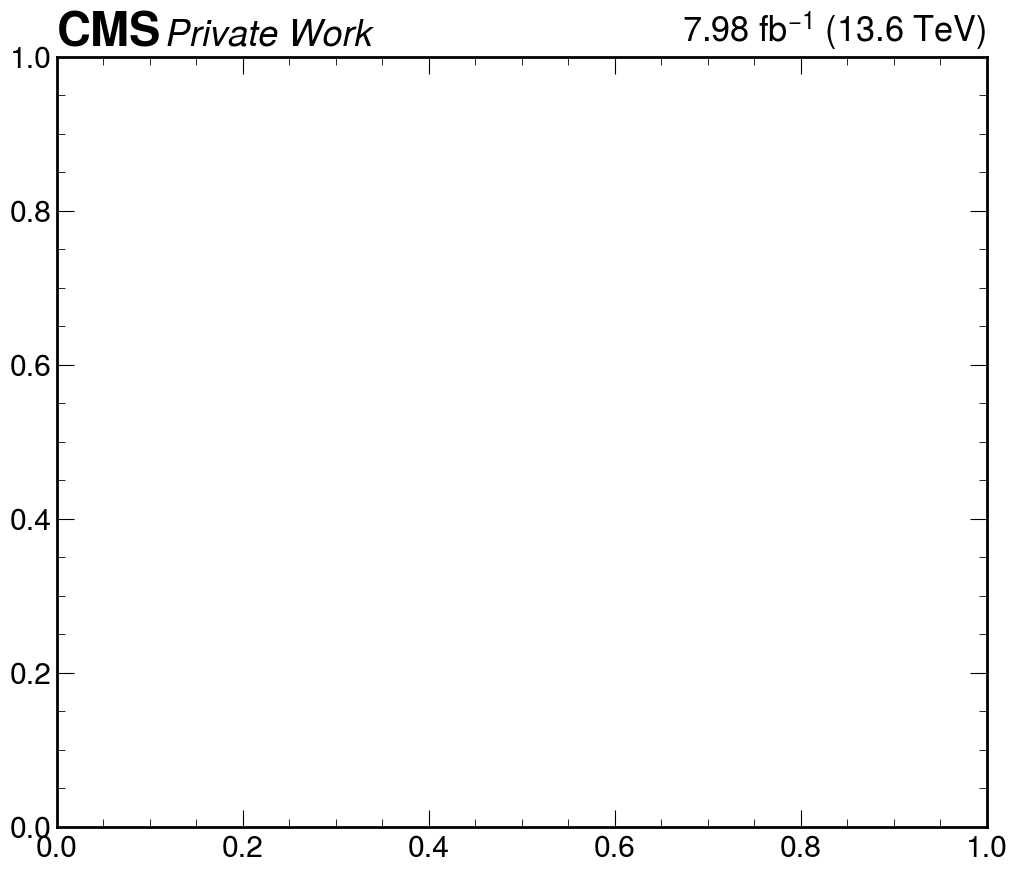

In [7]:
####
## myntuple draw
####
year = '2022'
lumi = {
    '2022': 7.98
}
region = 'eff'
vari = 'phopt'
bkg_hists = hists['bkg']
nevent = bkg_hists[vari]
#print(nevent)
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)

stack_hists = []
labels = []
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')

for k in bkg_hists[vari].keys():
    print(k)
    one_stack = bkg_hists[vari][k][{'region': region}]

    stack_hists.append(one_stack)
    labels.append(k)

stack_obj = hist.Stack(*stack_hists)

stack_obj.plot(stack=True, ax=ax, label=labels)

#ax.set_xlim(0,2000)
ax.legend()
#ax.set_ylim(0.01,1000000)
ax.set_yscale('log')
plt.show()
#plt.savefig('./egmNTuple_recoil.png')

G + Jets PT-100to200
G + Jets PT-200to400
G + Jets PT-400to600
G + Jets PT-600


/home/jieun/.local/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale


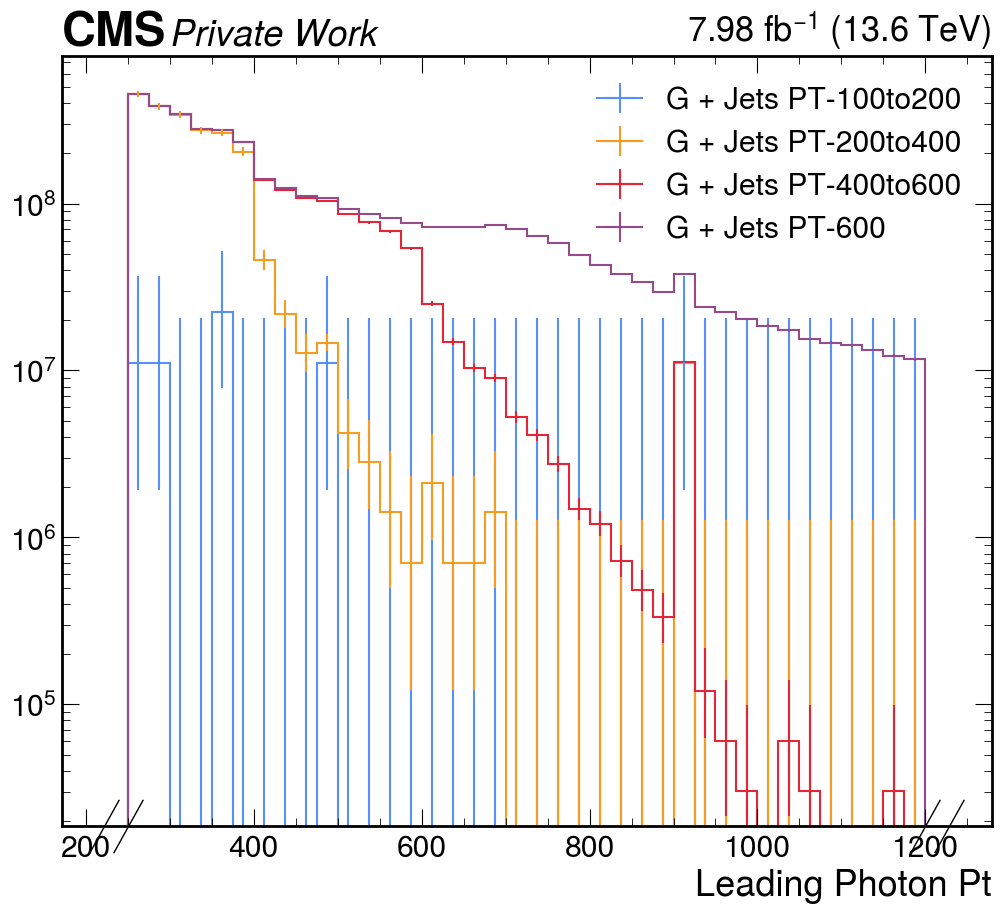

In [62]:
####
## myntuple draw
####
year = '2022'
lumi = {
    '2022': 7.98
}
region = 'pho200'
vari = 'phopt'
bkg_hists = hists['bkg']
nevent = bkg_hists[vari]
#print(nevent)
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)

stack_hists = []
labels = []
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')

for k in bkg_hists[vari].keys():
    print(k)
    one_stack = bkg_hists[vari][k][{'region': region}]

    stack_hists.append(one_stack)
    labels.append(k)

stack_obj = hist.Stack(*stack_hists)

stack_obj.plot(stack=True, ax=ax, label=labels)

#ax.set_xlim(0,2000)
ax.legend()
#ax.set_ylim(0.01,1000000)
ax.set_yscale('log')
plt.show()
#plt.savefig('./egmNTuple_recoil.png')

In [94]:
hists = load('./hadmonotoptrgefftestv1.scaled')

In [96]:
bkg_hists = hists['bkg']['template']
hist1 = bkg_hists['G + Jets PT-100to200']
print(hist1)
hist2 = hist1[{"region": 'total'}]
print(hist2)
ax = hist2.axes["PFHT1050"]
print(ax)
print(ax.edges)
print(hist2.values(flow=True))
#hist3 = hist2[{"PFHT1050": 1}]

Hist(
  StrCategory(['total', 'pho200'], growth=True, name='region'),
  Regular(60, 0, 1200, name='phopt', label='Photon Pt'),
  Variable([0, 1], name='PFHT1050', label='Reference trigger'),
  Variable([0, 1], name='Photon200', label='Photon trigger'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (WeightedSum(value=5.79284e+08, variance=6.45327e+15) with flow)
Hist(
  Regular(60, 0, 1200, name='phopt', label='Photon Pt'),
  Variable([0, 1], name='PFHT1050', label='Reference trigger'),
  Variable([0, 1], name='Photon200', label='Photon trigger'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0) (WeightedSum(value=3.34202e+08, variance=3.72304e+15) with flow)
Variable([0, 1], name='PFHT1050', label='Reference trigger')
[0. 1.]
[[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00]]

 [[0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00]
  [0.00

                       ┌─────────────────────────────────────────────────────┐
[-inf,    0) 0         │                                                     │
[   0,   20) 0         │                                                     │
[  20,   40) 0         │                                                     │
[  40,   60) 0         │                                                     │
[  60,   80) 0         │                                                     │
[  80,  100) 0         │                                                     │
[ 100,  120) 0         │                                                     │
[ 120,  140) 0         │                                                     │
[ 140,  160) 0         │                                                     │
[ 160,  180) 0         │                                                     │
[ 180,  200) 0         │                                                     │
[ 200,  220) 189381360 │████████████████████████████

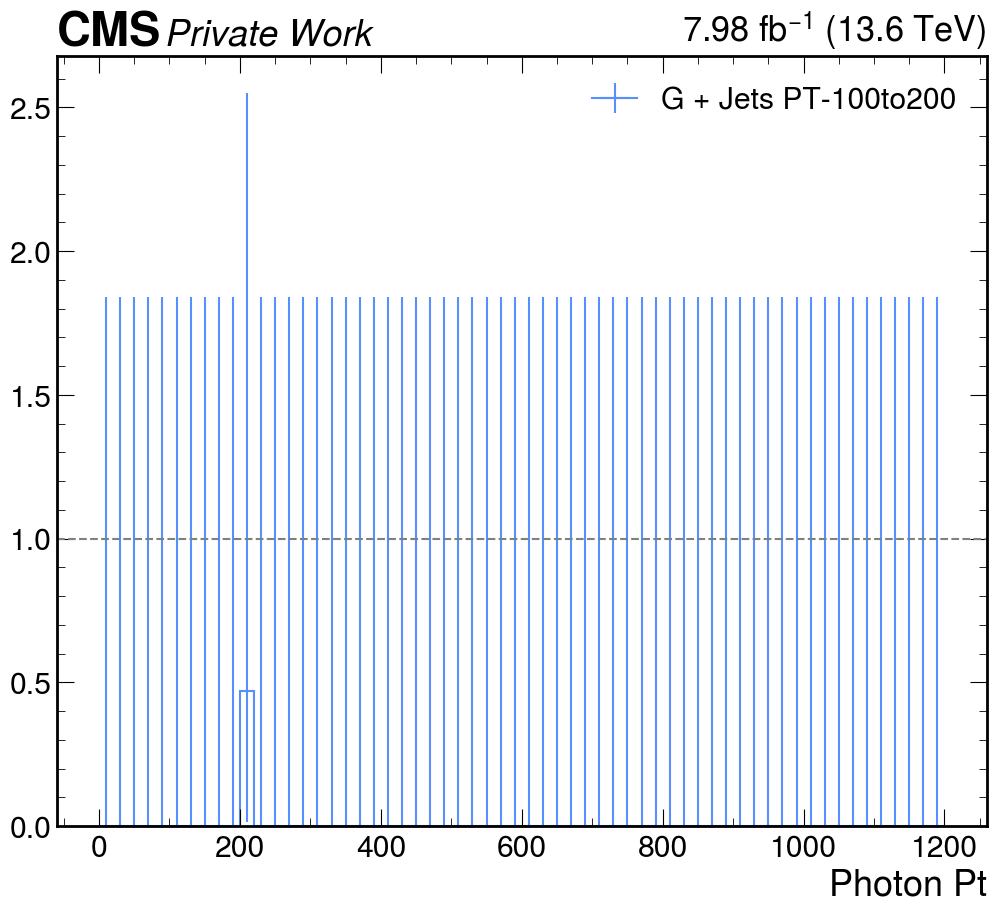

In [13]:
####
## myntuple draw
####
year = '2022'
lumi = {
    '2022': 7.98
}
region = 'basic'
vari = 'template'
bkg_hists = hists['bkg']
#print(total_hists)
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)

ratio_hists = []
ratio_labels = []
edges = [0, 200, 220, 240, 260, 280, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000]
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')

for k in bkg_hists[vari].keys():
    one_stack_total  = bkg_hists[vari][k][{'region': region, 'PFHT1050': 1, 'Photon200': sum}]
    one_stack_pho200 = bkg_hists[vari][k][{'region': region, 'PFHT1050': 1, 'Photon200': 0}]
    print(one_stack_total)

    rebin_total = one_stack_total#[{one_stack_total.axes[0].name : hist.rebin(edges)}]
    rebin_pho200 = one_stack_pho200#[{one_stack_pho200.axes[0].name, hist.rebin(edges)}]

    total_vals = rebin_total.values()
    pho200_vals = rebin_pho200.values()

    ratio_vals = np.divide(pho200_vals, total_vals,
                           out=np.zeros_like(pho200_vals),
                           where=total_vals > 0)
    ratio_hist = hist.Hist(one_stack_total.axes[0])
    ratio_hist.values()[...] = ratio_vals
    
    ratio_hists.append(ratio_hist)
    ratio_labels.append(k)
    break

for h, lab in zip(ratio_hists, ratio_labels):
    h.plot(ax=ax, label=lab)
print(ratio_hists)    
#stack_obj = hist.Stack(*stack_hists)

#stack_obj.plot(stack=True, ax=ax, label=labels)

#ax.set_xlim(0,2000)
ax.axhline(1, color='gray', linestyle='--')
ax.legend()
#ax.set_ylim(0.01,1000000)
#ax.set_yscale('log')
#plt.show()
#plt.savefig('./egmNTuple_recoil.png')


Bin 0: [(0.0, 20.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 1: [(20.0, 40.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 2: [(40.0, 60.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 3: [(60.0, 80.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 4: [(80.0, 100.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 5: [(100.0, 120.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 6: [(120.0, 140.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 7: [(140.0, 160.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 8: [(160.0, 180.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 9: [(180.0, 200.0)] total = [[0. 0.]
 [0. 0.]], pho200 = [[0. 0.]
 [0. 0.]]
Bin 10: [(200.0, 219.99999999999997)] total = [[0.0000000e+00 0.0000000e+00]
 [8.9120640e+07 1.0026072e+08]], pho200 = [[0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 1.0026072e+08]]
Bin 11: [(219.99999999999997

ValueError: x and y can be no greater than 2D, but have shapes (60,) and (60, 2, 2)

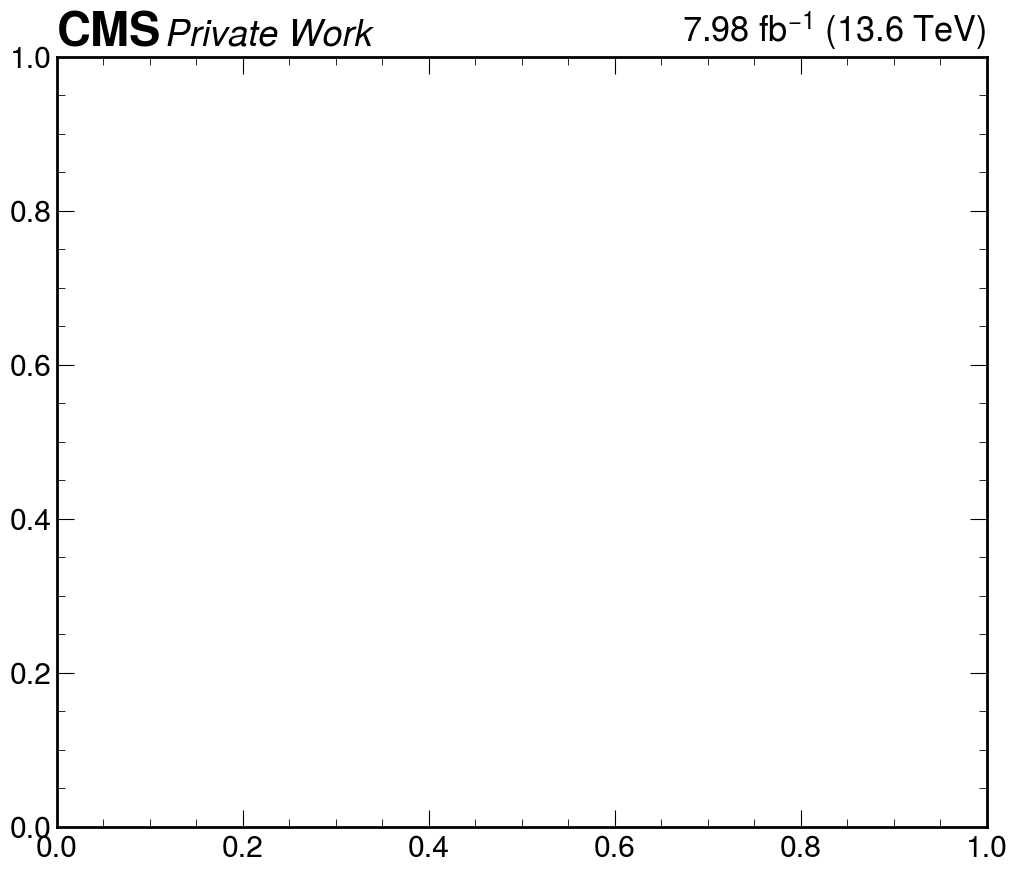

In [12]:
####
## myntuple draw
####
year = '2022'
lumi = {
    '2022': 7.98
}
region = 'basic'
vari = 'template'
bkg_hists = hists['bkg']
nevent = bkg_hists[vari]
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)

stack_hists = []
labels = []
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13.6 TeV)')

for k in bkg_hists[vari].keys():
    one_stack_total  = bkg_hists[vari][k][{'region': 'total'}]
    one_stack_pho200 = bkg_hists[vari][k][{'region': 'pho200'}]

    total_vals = one_stack_total.values()
    pho200_vals = one_stack_pho200.values()

    ratio_vals = np.divide(
        pho200_vals, total_vals,
        out=np.zeros_like(pho200_vals),
        where=total_vals > 0
    )
    break
x = one_stack_total.axes[0].centers

#print(one_stack_total.axes[0].edges)
#print(one_stack_total.values())
#print(one_stack_pho200.values())

total_vals = one_stack_total.values()
pho200_vals = one_stack_pho200.values()
edges = one_stack_total.axes[0].edges

for i in range(len(one_stack_total.values())):
    print(f"Bin {i}: [{edges[i], edges[i+1]}] total = {total_vals[i]}, pho200 = {pho200_vals[i]}")

ax.plot(x, ratio_vals, marker='o')
ax.axhline(1.0, color='gray', linestyle='--')

#ax.set_xlim(0,2000)
ax.legend()
ax.set_ylim(-2,2)
#ax.set_yscale('log')
plt.show()
#plt.savefig('./egmNTuple_recoil.png')